Figure XX - iPSCs PuroR Conventional Cassette

WT iPS11s were infected at low MOI. After the first passage they were flowed to determined the GFP%.

For each biorep one 6-well of iPS11s and one 6-well of transduced iPSCs were dissociated, counted, mixed at given ratios and reseeded at 100k onto 24-wells. THe following 2 days media was changed with 1 ug/mL of puromycin. 3 days post seeding conditions were flowed.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rushd as rd
import scipy as sp
import seaborn as sns

Loading data

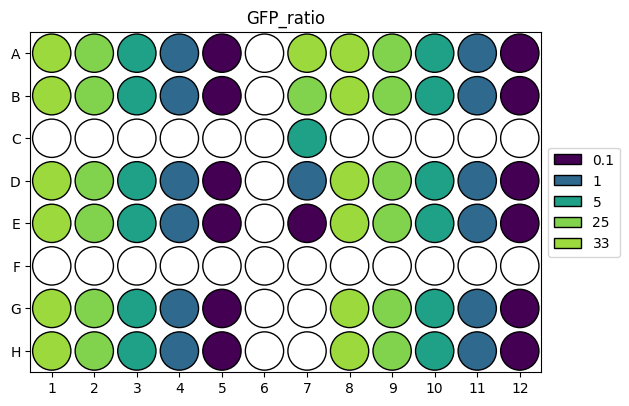

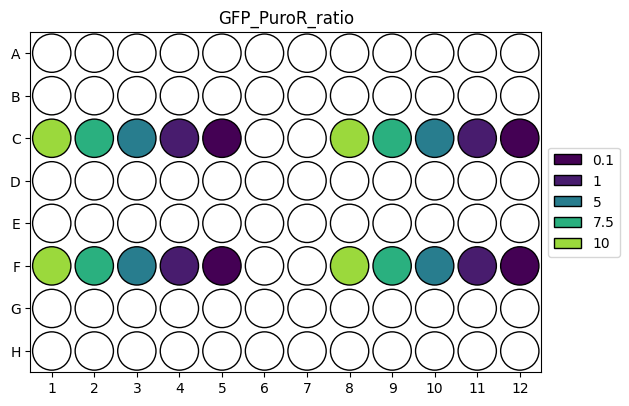

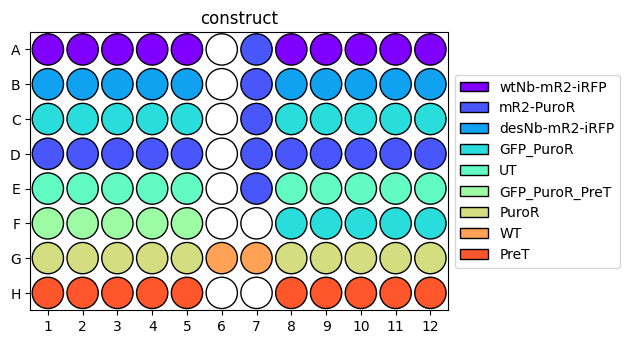

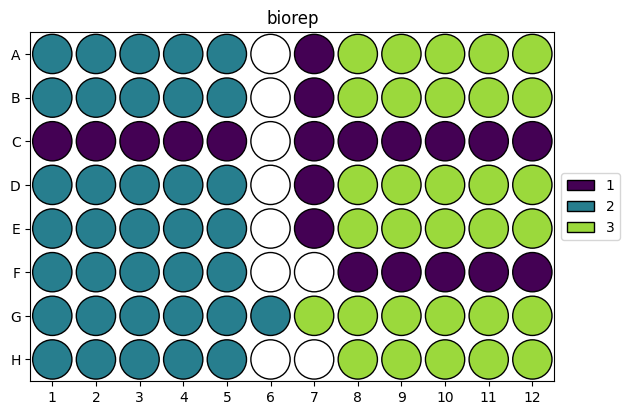

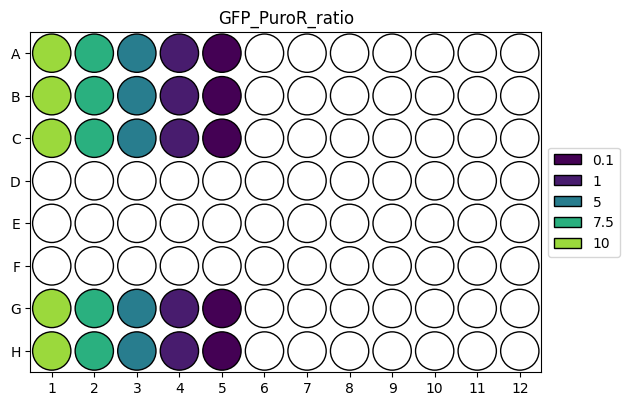

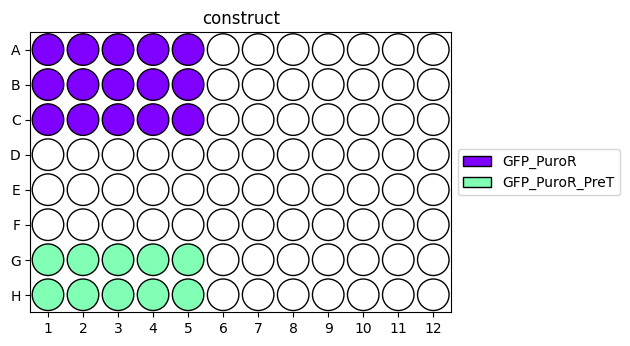

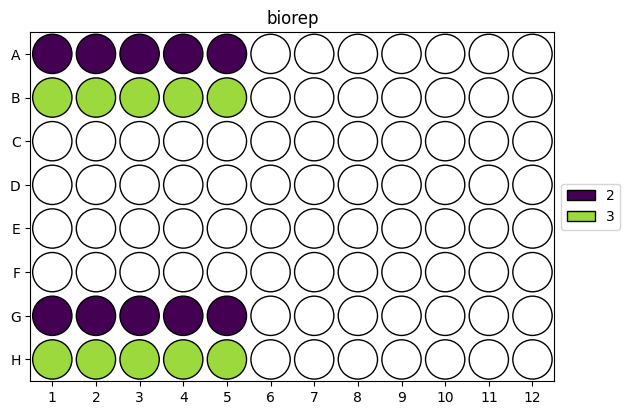

In [9]:
base_path = rd.datadir/'data'/'attune'/'Derin'
plates = pd.DataFrame({'data_path': ['2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV', '2026.7.06_iPS11_EGFP-PuroR_dilution_Biorep2&3/CSV'], 
                       'yaml_path': ['2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV/wells_metadata.yaml', '2026.7.06_iPS11_EGFP-PuroR_dilution_Biorep2&3/CSV/wells_metadata.yaml'],
                       'plate':range(1,3)})
output_path = rd.rootdir/'output'/'Figure_S7_lenti'

for p in plates['yaml_path'].unique():
    rd.plot.plot_well_metadata(base_path/p)

In [4]:
data = pd.DataFrame()
channel_list = ['SSC-A', 'FSC-A', 'EGFP-A'] # for loading with rushd purposes

cache_path = output_path/'data.gzip'

if cache_path.exists():
    data = rd.flow.load_groups_with_metadata(plates, base_path, columns=channel_list)
else:
    data = rd.flow.load_groups_with_metadata(plates, base_path, columns=channel_list)
    data.to_parquet(rd.outfile(cache_path))

data = data[data.construct.isin(['GFP_PuroR', 'GFP_PuroR_PreT', 'WT'])]

data["selection"] = data["construct"].map({
    "GFP_PuroR_PreT": "Pre-Puro",
    "GFP_PuroR": "Post-Puro",
    "WT": "WT"
})

display(data)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore


,GFP_ratio,GFP_PuroR_ratio,construct,biorep,well,population,FSC-A,SSC-A,EGFP-A,plate,selection
2543419,<NA>,5.0,GFP_PuroR,1,C10,Single Cells,517972,265749,38933,1,Post-Puro
2543420,<NA>,5.0,GFP_PuroR,1,C10,Single Cells,398668,254590,1571,1,Post-Puro
2543421,<NA>,5.0,GFP_PuroR,1,C10,Single Cells,448043,153671,238,1,Post-Puro
2543422,<NA>,5.0,GFP_PuroR,1,C10,Single Cells,429631,177844,34869,1,Post-Puro
2543423,<NA>,5.0,GFP_PuroR,1,C10,Single Cells,381400,277926,23826,1,Post-Puro
...,...,...,...,...,...,...,...,...,...,...,...
13065882,<NA>,0.1,GFP_PuroR_PreT,3,H5,Single Cells,353200,145833,29,2,Pre-Puro
13065883,<NA>,0.1,GFP_PuroR_PreT,3,H5,Single Cells,246567,209488,157,2,Pre-Puro
13065884,<NA>,0.1,GFP_PuroR_PreT,3,H5,Single Cells,453366,249552,-24,2,Pre-Puro
13065885,<NA>,0.1,GFP_PuroR_PreT,3,H5,Single Cells,427108,219576,95,2,Pre-Puro


In [5]:
# PUll out the data that has biorep metadata assigned for plotting
plot_data = data.loc[data["biorep"].notna()].copy()

#Define the GFP gate based on the 99.9 percentil of the WT population
EGFP = "EGFP-A"
EGFP_gate = plot_data.loc[plot_data["construct"] == "WT", EGFP].quantile(0.999)

print(f"EGFP gate: {EGFP_gate:.2f}")

#Assign for each cell whether it is GFP+/-
plot_data["GFP_positive"] = plot_data[EGFP] > EGFP_gate

EGFP gate: 436.00


Generate summary table with total cell count, GFP+ cell count, and GFP+ %

In [6]:
nonWT_data = plot_data.loc[plot_data["selection"].isin(["Pre-Puro", "Post-Puro"])].copy()

summary = (nonWT_data.groupby(["biorep", "GFP_PuroR_ratio", "selection"],observed=True).agg(
        total_cell_count=(EGFP, "size"),
        GFP_positive_count=("GFP_positive", "sum")
    ).reset_index())

summary["percent_GFP_positive"] = (summary["GFP_positive_count"]/ summary["total_cell_count"]* 100)

display(summary)

,biorep,GFP_PuroR_ratio,selection,total_cell_count,GFP_positive_count,percent_GFP_positive
0,1,0.1,Post-Puro,115296,102811,89.171350
1,1,1.0,Post-Puro,646671,582453,90.069448
2,1,5.0,Post-Puro,244564,232051,94.883548
3,1,7.5,Post-Puro,323213,299384,92.627462
4,1,10.0,Post-Puro,436240,391015,89.633000
5,2,0.1,Post-Puro,9424,8972,95.203735
6,2,0.1,Pre-Puro,88121,119,0.135042
7,2,1.0,Post-Puro,20074,18733,93.319717
8,2,1.0,Pre-Puro,71516,660,0.922870
9,2,5.0,Post-Puro,17122,16248,94.895456


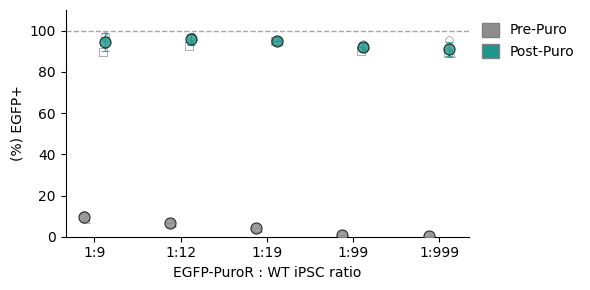

In [7]:
from matplotlib.patches import Patch

ratio_order = [10, 7.5, 5, 1, 0.1]
selection_order = ["Pre-Puro", "Post-Puro"]

palette = { "Pre-Puro": "#8E8E8E", "Post-Puro": "#1F968BFF"}

markers = {
    1: "s",
    2: "o",
    3: "^"
}

y = "percent_GFP_positive"

#Biorep mean
bio_means = summary.copy()

# Mean + SD across biological replicates
plot_summary = (bio_means.groupby(["selection", "GFP_PuroR_ratio"],as_index=False, observed=True)
    .agg( mean=(y, "mean"), sd=(y, "std")))

#Barplot with individual bioreps 
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

group_centers = np.arange(len(ratio_order))

# offsets for Pre vs Post
offsets = {
    "Pre-Puro": -0.12,
    "Post-Puro": 0.12
}

# tiny offsets so biological replicate points don't perfectly overlap
rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}


for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for selection in selection_order:

            row = rep_data.loc[
                (rep_data["GFP_PuroR_ratio"] == ratio) &
                (rep_data["selection"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[selection]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# ---------------------------------------------------------
# Mean ± SD — front layer
# ---------------------------------------------------------

for i, ratio in enumerate(ratio_order):

    for selection in selection_order:

        row = plot_summary.loc[
            (plot_summary["GFP_PuroR_ratio"] == ratio) &
            (plot_summary["selection"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[selection]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# Formatting

ax.set_ylabel("(%) EGFP+")
ax.set_xlabel("EGFP-PuroR : WT iPSC ratio")

ax.set_ylim(0, 110)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:9",
    "1:12",
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)

sns.despine()

# Legend

legend_handles = [
    Patch(
        facecolor=palette["Pre-Puro"],
        edgecolor="grey",
        label="Pre-Puro"
    ),
    Patch(
        facecolor=palette["Post-Puro"],
        edgecolor="grey",
        label="Post-Puro"
    )
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


# Optional 100% reference line
ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

fig.tight_layout()
plt.show()

1_Pre-Puro vs. 1_Post-Puro: ***
5_Pre-Puro vs. 5_Post-Puro: ****
0.1_Pre-Puro vs. 0.1_Post-Puro: ***


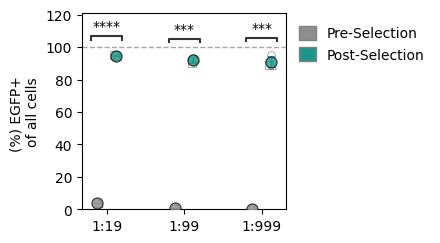

In [10]:
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
from statannotations.Annotator import Annotator

ratio_order = [5, 1, 0.1]
selection_order = ["Pre-Puro", "Post-Puro"]

x = "GFP_PuroR_ratio"
y = "percent_GFP_positive"
hue = "selection"

palette = {
    "Pre-Puro": "#8E8E8E",
    "Post-Puro": "#1F968BFF"
}

markers = {
    1: "s",
    2: "o",
    3: "^"
}


# Calculate plotted values (mean ± SD) across bioreps

bio_means = summary.loc[(summary["selection"].isin(selection_order)) & (summary["GFP_PuroR_ratio"].isin(ratio_order))].copy()

plot_summary = (bio_means.groupby(["selection", "GFP_PuroR_ratio"],as_index=False,observed=True)
    .agg(
        mean=(y, "mean"),
        sd=(y, "std")
    )
)


#Plot scatter plot w/ overlayed mean +SD errorbars 
fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

group_centers = np.arange(len(ratio_order))

offsets = {
    "Pre-Puro": -0.12,
    "Post-Puro": 0.12
}

rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}

# ---------------------------------------------------------
# Individual biological replicate points
# ---------------------------------------------------------

for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for selection in selection_order:

            row = rep_data.loc[
                (rep_data["GFP_PuroR_ratio"] == ratio) &
                (rep_data["selection"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[selection]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# Mean ± SD
for i, ratio in enumerate(ratio_order):

    for selection in selection_order:

        row = plot_summary.loc[
            (plot_summary["GFP_PuroR_ratio"] == ratio) &
            (plot_summary["selection"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[selection]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# Formatting

ax.set_ylabel("(%) EGFP+ \nof all cells")
ax.set_xlabel("")

ax.set_ylim(0, 110)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)



# Legend
legend_handles = [
    Patch(
        facecolor=palette["Pre-Puro"],
        edgecolor="grey",
        label="Pre-Selection"
    ),
    Patch(
        facecolor=palette["Post-Puro"],
        edgecolor="grey",
        label="Post-Selection"
    )
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


# Statistical tests: Pre-Puro vs Post-Puro at each ratio

pairs = [
    ((ratio, "Pre-Puro"), (ratio, "Post-Puro"))
    for ratio in ratio_order
]

annotations = []

for ratio in ratio_order:

    vals_pre = bio_means.loc[
        (bio_means["GFP_PuroR_ratio"] == ratio) &
        (bio_means["selection"] == "Pre-Puro"),
        y
    ]

    vals_post = bio_means.loc[
        (bio_means["GFP_PuroR_ratio"] == ratio) &
        (bio_means["selection"] == "Post-Puro"),
        y
    ]

    _, p = ttest_ind(
        vals_pre,
        vals_post,
        equal_var=False
    )

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


# Add statistical annotations
annotator = Annotator(
    ax,
    pairs=pairs,
    data=bio_means,
    x=x,
    y=y,
    hue=hue,
    order=ratio_order,
    hue_order=selection_order
)

annotator.configure(
    text_format="full",
    loc="inside",
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()

fig.tight_layout()

plottitle = "Figure_XX_iPSCs_controls_puroR_purity_lenti.svg"

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches="tight"
)

plt.show()